# Mintavételezési arány beállítása

A `collect_time_evolution1` függvény most már paraméterben tudja fogadni a mintavételezési arányt:
- `sampling_ratio = 10`: minden 10. időlépést ment (alapértelmezett)
- `sampling_ratio = 5`: minden 5. időlépést ment
- `sampling_ratio = 20`: minden 20. időlépést ment

Ezzel jelentősen csökkenthető a memóriaigény és a számítási idő.

In [1]:
# import h5py
# from datetime import datetime

# # File to store complete simulation configuration and metadata
# config_file = "simulation_config.h5"

# # Add metadata to configuration
# config.metadata.update({
#     'created_date': datetime.now().isoformat(),
#     'description': 'Time evolution with unified configuration system',
#     'version': '1.0',
#     'author': 'NEGF simulation'
# })

# # Save complete configuration to HDF5
# with h5py.File(config_file, "w") as hdf:
#     config.to_hdf5_group(hdf.create_group("simulation_config"))
    
# print(f"Complete simulation configuration saved to {config_file}")
# print("This includes:")
# print("  - Laser parameters")
# print("  - Grid configuration") 
# print("  - Potential settings")
# print("  - Computational parameters")
# print("  - Metadata")

# # Demonstrate loading (optional)
# print(f"\nConfiguration can be reloaded with:")
# print(f"with h5py.File('{config_file}', 'r') as hdf:")
# print(f"    loaded_config = SimulationConfig.from_hdf5_group(hdf['simulation_config'])")

# # Legacy output file name for backward compatibility
# output_file = "simulation_metadata.h5"

# Set Atomic unit system

In [2]:
import atomic_units as au

hbar=1.0
me=8.8
kappa0=2.3 # 4*pi*epsilon0
e0=3.4

unit_sys = au.AtomicUnitSystem(xh=hbar, xe=e0, xm=me, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))

0.007297352569307101 dimensionless
0.12240749165941847 electron_volt
2.340527796123471 nanometer


# Set Laser parameters

In [3]:
# from utils.simulation_config import SimulationConfig, create_standard_config

# # Create unified simulation configuration
# config = create_standard_config(
#     # Laser parameters
#     spot_size_nm=400,  # nm
#     magnitude_gvm=1.0,  # GV/m
#     central_wavelength_nm=800,  # nm
#     num_cycles=5,  # one cycle is around 2.66 fs
    
#     # Grid parameters (will override defaults where specified)
#     x_points=16*1024,
#     x_step=0.025,
#     t_points=50000,
#     t_start=0,
#     t_stop=200.0,
    
#     # Computational parameters
#     sampling_ratio=20
# )

# # Display configuration summary
# config.info()

# print("\n" + "="*50)
# print("LEGACY COMPATIBILITY VARIABLES")
# print("="*50)

# # For backward compatibility, extract individual variables
# # (these can be gradually phased out)
# spot_size_nm = config.laser.spot_size_nm
# magnitude_of_electric_field_gvm = config.laser.magnitude_gvm
# central_wavelength_nm = config.laser.central_wavelength_nm
# num_of_cycles = config.laser.num_cycles

# print(f"Legacy variables extracted:")
# print(f"  spot_size_nm = {spot_size_nm}")
# print(f"  magnitude_of_electric_field_gvm = {magnitude_of_electric_field_gvm}")
# print(f"  central_wavelength_nm = {central_wavelength_nm}")
# print(f"  num_of_cycles = {num_of_cycles}")

In [4]:
from utils import SimulationGrid
# Create Grid object
grid = SimulationGrid(
    x_points=16*1024,
    x_step=0.025,  # nm
    t_points=25000,
    t_start=0.0,  # fs
    t_stop=250.0  # fs
    # x_points=8*1024,
    # x_step=0.045,  # nm
    # t_points=50000,
    # t_start=0,
    # t_stop=200.0
)

In [5]:
# Create simulation grid from configuration
sim_grid = grid

# Add masks as before
# Uniform sampling - same grid, but with fewer points for plotting
sim_grid.add_mask(
    grid_type="spatial",
    name="uniform_subsampling",
    mask_type="uniform", 
    desired_points=2048
)

sim_grid.add_mask(
    grid_type="temporal",
    name="uniform_subsampling",
    mask_type="uniform", 
    desired_points=2048
)

# Spatial mask - center region
sim_grid.add_mask(
    grid_type="spatial",
    name="center",
    mask_type="center",
    center=0,
    width=5
)
# Temporal mask - center region
sim_grid.add_mask(
    grid_type="temporal",
    name="center",
    mask_type="range",
    start=0,
    stop=100.0
)

print(f"Spatial grid created with {sim_grid.spatial.num} points")
print(f"Temporal grid created with {sim_grid.temporal.num} points")
#print(f"Configuration-based grid matches expectations: x_points={config.grid.x_points}, x_step={config.grid.x_step}")

Spatial grid created with 16384 points
Temporal grid created with 25000 points


# Set unified grid

### Spatial grid

In [6]:
uxgrid = sim_grid.spatial.values

print(type(uxgrid))
uxgrid_dx = sim_grid.spatial.delta
uxgrid_width = sim_grid.spatial.width
uxgrid_num = sim_grid.spatial.num

print("Spatial grid:")
print(uxgrid_num, uxgrid_dx, uxgrid_width)
print(type(uxgrid)) 
print(uxgrid.min(), uxgrid.max(), uxgrid[1]-uxgrid[0], uxgrid.size)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
Spatial grid:
16384 0.025 409.6
<class 'numpy.ndarray'>
-204.8 204.77500000000003 0.025000000000005684 16384
409.6
958.6801852921737 nanometer


### Spatial mask

In [7]:
import numpy as np

# Mask lekérése a simulation_grid modullal
mask_arr = sim_grid.get_mask('spatial',"uniform_subsampling")
print(f"Mask array shape: {mask_arr.shape}")
print(f"Number of True values: {np.sum(mask_arr)}")

# Maszkolt grid lekérése
masked_x = sim_grid.spatial("uniform_subsampling")
print(f"Masked grid shape: {masked_x.shape}")

Mask array shape: (16384,)
Number of True values: 2048
Masked grid shape: (2048,)


### Temporal grid

In [8]:
t_start=sim_grid.temporal.start
t_stop=sim_grid.temporal.stop
t_num=sim_grid.temporal.num

utgrid = sim_grid.temporal.values
utgrid_dt = sim_grid.temporal.delta

print(uxgrid_dx**2)
print(utgrid_dt)
print(f"Temporal grid: {t_num} points from {t_start} to {t_stop}")

0.0006250000000000001
0.01
Temporal grid: 25000 points from 0.0 to 250.0


In [9]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.CosineDispersion(uxgrid_dx, hbar = unit_sys.hb, mass = unit_sys.me)

# Set model-potential

8.169434619102878
0.0
0.12240749165941847
1.2817621755950894
4.272540585316965


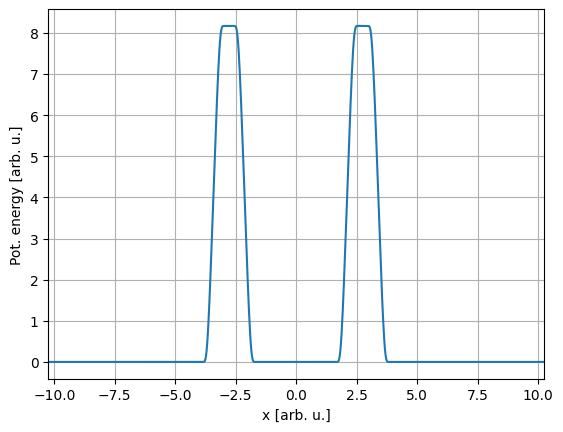

In [10]:
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import pint


wall_in_unit_sys = 1.0 * unit_sys.convert_energy_from('eV')
print(wall_in_unit_sys)


well_in_unit_sys = 0.0 * unit_sys.convert_energy_from('eV')
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = 3 * unit_sys.convert_length_from('nm')
print(wall_width)
well_width = 10 * unit_sys.convert_length_from('nm')
print(well_width)

cell_width_au = 2* wall_width + well_width 
cell_width_nm = cell_width_au * length_unit_in_nm

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 1,\
                                   wellfall = 1)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-1.5*cell_width_au, 1.5*cell_width_au])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


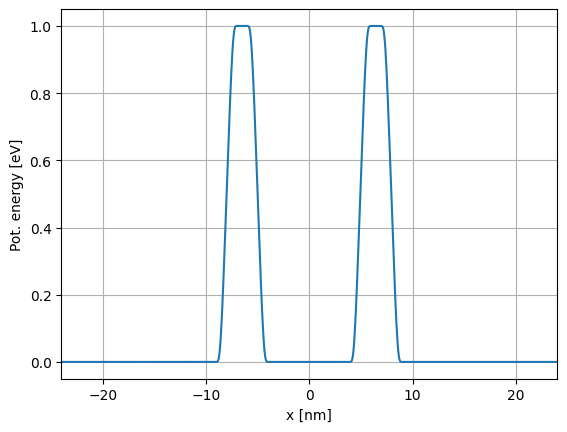

In [11]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
plt.xlim([-1.5*cell_width_nm, 1.5*cell_width_nm])
plt.grid()
plt.show()

In [12]:
zeropot=pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [13]:
t_vals=[]
r_vals=[]

energy_min = 0.9
energy_max = 1.4
number_of_points_in_energy = 11

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.wavenumber(energy_min_in_unit_sys)
k_max = dispersion.wavenumber(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,number_of_points_in_energy)

print(k_min,k_max,k_vals)

e_vals=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.energy(k)
    e_vals.append(ein)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    t_vals.append(qp_pk.transmission)
    r_vals.append(qp_pk.reflection)

    print(kin)

    num=len(t_vals)

    # plt.plot(k_vals[:num],t_vals,"-o",label="T")
    # plt.plot(k_vals[:num],r_vals,"-o",label="R")
    # plt.xlabel("k [arb. u.]")
    # #plt.ylabel("Coefficient")
    # plt.legend()
    # plt.grid()
    # plt.show()

11.414268584013065 14.263288516612283 [11.41426858 11.69917058 11.98407257 12.26897456 12.55387656 12.83877855
 13.12368054 13.40858254 13.69348453 13.97838652 14.26328852]
11.414268584013065
11.699170577272987
11.98407257053291
12.268974563792831
12.553876557052753
12.838778550312675
13.123680543572597
13.408582536832517
13.693484530092439
13.978386523352361
14.263288516612283


In [14]:
import h5py

output_file = "quasiparticles_wall.h5"
with h5py.File(output_file, "w") as hdf:
    grp_particles = hdf.create_group("particles")
    for i, (qp_pk, qp_mk) in enumerate(zip(quasiparticles_pk, quasiparticles_mk)):
        grp_index = grp_particles.create_group(f"{i}.")
        grp_index.attrs["energy"] = qp_pk.angular_frequency * unit_sys.hb

        # Save particle with positive k using QuasiParticle method
        pk_grp = grp_index.create_group("positive_k")
        qp_pk.to_hdf5_group(pk_grp)

        # Save particle with negative k using QuasiParticle method
        mk_grp = grp_index.create_group("negative_k")
        qp_mk.to_hdf5_group(mk_grp)
        
print(f"Saved to {output_file}")

Saved to quasiparticles_wall.h5


In [13]:
def load_quasiparticles_from_hdf5(filename):
    quasiparticles_pk = []
    quasiparticles_mk = []
    e_vals = []
    k_vals = []
    t_vals=[]
    r_vals=[]
    import h5py
    from quantum_toolkit.quantum_transport_toolkit import QuasiParticle
    with h5py.File(filename, "r") as hdf:
        particles_group = hdf["particles"]
        # --- csoportnevek rendezése numerikusan ---
        group_names = sorted(particles_group.keys(), key=lambda x: int(x.rstrip('.')))
        for group_name in group_names:
            group = particles_group[group_name]
            e_vals.append(group.attrs["energy"])
            print(f"Processing group: {group_name}, energy: {group.attrs['energy']}")
            # Positive k
            pk = QuasiParticle.from_hdf5_group(group["positive_k"])
            # Negative k
            mk = QuasiParticle.from_hdf5_group(group["negative_k"])
            k_vals.append(pk.wavenumber)
            t_vals.append(pk.transmission)
            r_vals.append(pk.reflection)
            quasiparticles_pk.append(pk)
            quasiparticles_mk.append(mk)
    return e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk

# Példa használat:
e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk = load_quasiparticles_from_hdf5("quasiparticles_wall.h5")

Processing group: 0., energy: 7.352491157192597
Processing group: 1., energy: 7.721458178944529
Processing group: 2., energy: 8.099257214819763
Processing group: 3., energy: 8.485869098883683
Processing group: 4., energy: 8.881274218121458
Processing group: 5., energy: 9.285452513433095
Processing group: 6., energy: 9.698383480650874
Processing group: 7., energy: 10.120046171579677
Processing group: 8., energy: 10.550419195059732
Processing group: 9., energy: 10.989480718051603
Processing group: 10., energy: 11.437208466744027


In [14]:
print(e_vals)

[7.352491157192597, 7.721458178944529, 8.099257214819763, 8.485869098883683, 8.881274218121458, 9.285452513433095, 9.698383480650874, 10.120046171579677, 10.550419195059732, 10.989480718051603, 11.437208466744027]


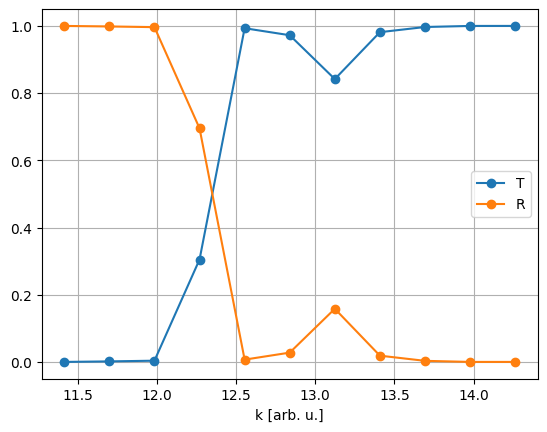

In [15]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

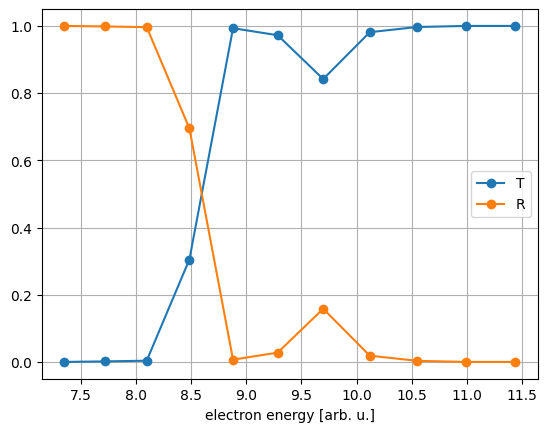

In [16]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [17]:
from utils.parameters import laser_parameters_converter

params = laser_parameters_converter(
    spot_size=200*unit_sys.ureg('nm'),
    magnitude=1.0*unit_sys.ureg('GV/m'),
    wavelength=800*unit_sys.ureg('nm'),
    num_cycles=5,
    beta=0.2,
    unit_sys=unit_sys
)

laserpot = pots.SmoothLaserPotential(
    uxgrid,
    spatial_min=params["spatial_min"],
    spatial_max=params["spatial_max"],
    temporal_max=params["temporal_max"],
    temporal_min=params["temporal_min"],
    noc=params["noc"],
    amplitude=params["amplitude"],
    beta=params["beta"]
)

laserpot_masked = pots.SmoothLaserPotential(
    uxgrid[mask_arr],
    spatial_min=params["spatial_min"],
    spatial_max=params["spatial_max"],
    temporal_max=params["temporal_max"],
    temporal_min=params["temporal_min"],
    noc=params["noc"],
    amplitude=params["amplitude"],
    beta=params["beta"]
)

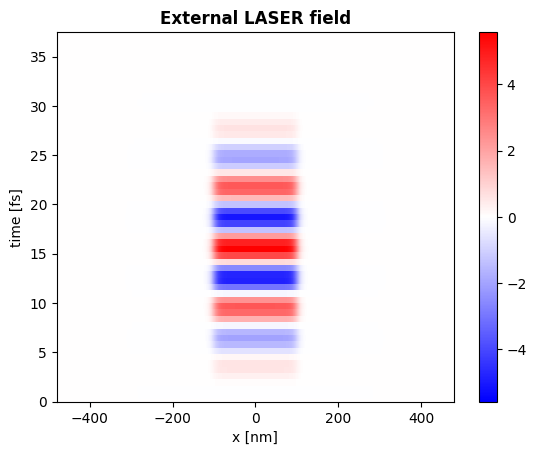

In [18]:
X,Y = np.meshgrid(uxgrid[mask_arr],sim_grid.temporal("uniform_subsampling"))
X_nm,Y_fs = np.meshgrid(uxgrid[mask_arr]*unit_sys.length_unit.to('nm').magnitude,\
                  sim_grid.temporal("uniform_subsampling")*unit_sys.time_unit.to('fs').magnitude)

Z=laserpot_masked(Y)

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X_nm, Y_fs, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('External LASER field', fontweight ="bold")
plt.ylim(0.0,1.2*laserpot_masked.temporal_max*unit_sys.time_unit.to('fs').magnitude)
#plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
plt.xlabel("x [nm]")
plt.ylabel("time [fs]")
plt.show()

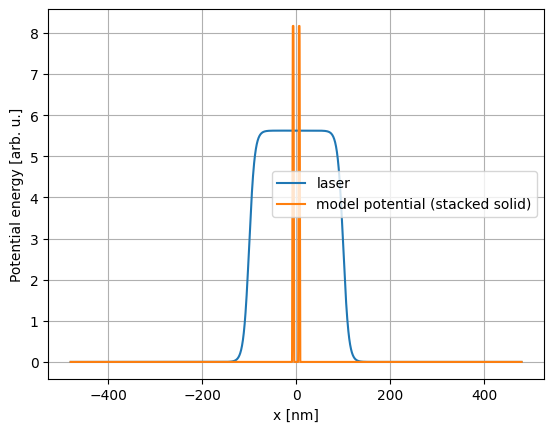

In [19]:
plt.plot(uxgrid[mask_arr]*unit_sys.length_unit.to("nm"),\
          laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          modelpot(uxgrid[mask_arr]),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

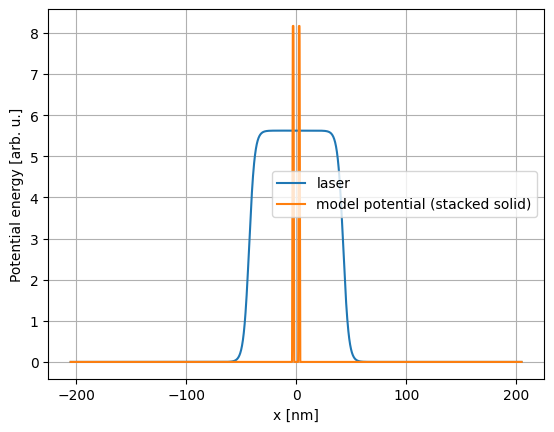

In [20]:
plt.plot(uxgrid[mask_arr],\
          laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid,\
          modelpot(uxgrid[mask_arr]),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

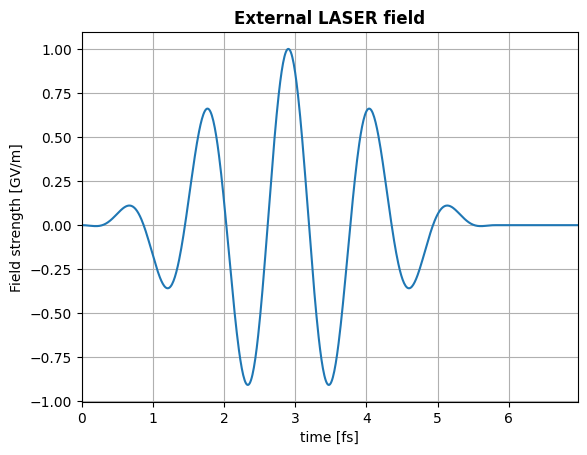

In [21]:
plt.plot(utgrid,\
          laserpot.value_at(0.0,utgrid)*unit_sys.electric_field_unit.to('GV/m'),\
          label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [GV/m]")
plt.title('External LASER field', fontweight ="bold")
plt.xlim(0,1.2*laserpot.temporal_width)
plt.grid()
plt.show()

# Select initial state

8.881274218121458 1.0871344997797108 electron_volt
12.553876557052753 5.363694709306709 / nanometer


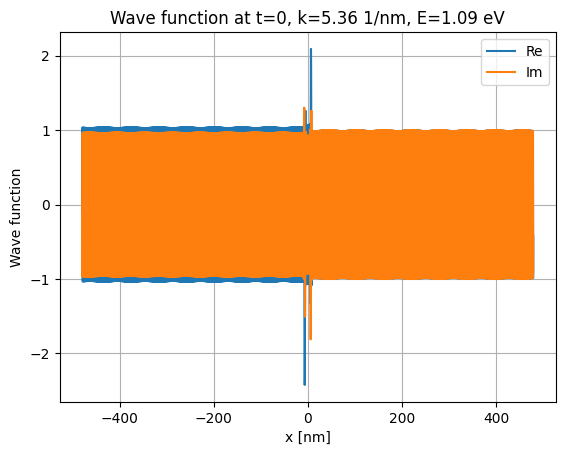

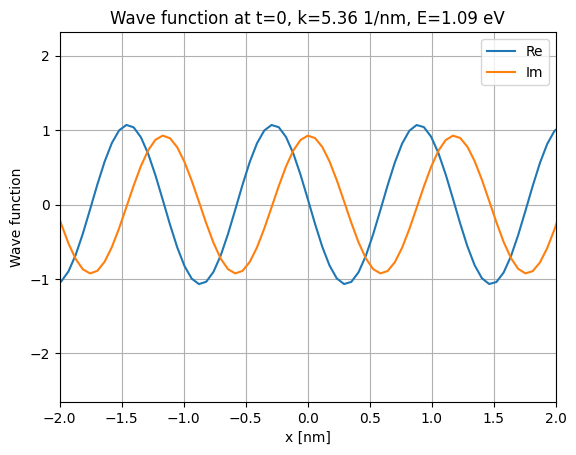

In [22]:
from quantum_toolkit import quantum_transport_toolkit as trat

qp_index = 4

qppk, qpmk = quasiparticles_pk[qp_index], quasiparticles_mk[qp_index]

ein=qppk.angular_frequency * unit_sys.hb
kin=qppk.wavenumber

print(ein,ein*unit_sys.energy_unit.to('eV'))
print(kin,kin*unit_sys.wavenumber_unit.to('1/nm'))

initial_state = qppk.state

plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.real(initial_state.value),label="Re")
plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.imag(initial_state.value),label="Im")
plt.xlabel("x [nm]")
plt.ylabel("Wave function")
plt.title(f"Wave function at t=0, k={kin*unit_sys.wavenumber_unit.to('1/nm').magnitude:.2f} 1/nm, E={ein*unit_sys.energy_unit.to('eV').magnitude:.2f} eV")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.real(initial_state.value),label="Re")
plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.imag(initial_state.value),label="Im")
plt.xlabel("x [nm]")
plt.xlim([-2, 2])
plt.ylabel("Wave function")
plt.title(f"Wave function at t=0, k={kin*unit_sys.wavenumber_unit.to('1/nm').magnitude:.2f} 1/nm, E={ein*unit_sys.energy_unit.to('eV').magnitude:.2f} eV")
plt.legend()
plt.grid()
plt.show()

In [23]:
# Get measurement points from configuration
measurement_points = [-80,80]
meas_point_left = measurement_points[0]
meas_point_right = measurement_points[1]

print(f"Measurement points from configuration:")
print(f"  Left: {meas_point_left}")
print(f"  Right: {meas_point_right}")

Measurement points from configuration:
  Left: -80
  Right: 80


# Vcap check

In [24]:
print(uxgrid[0], uxgrid[-1])
print(0.9*uxgrid[0], 0.9*uxgrid[-1])

-204.8 204.77500000000003
-184.32000000000002 184.29750000000004


In [25]:
v_cap=quat.vcap_generator(uxgrid,param_x0=184,param_lambda0 = 0.3,param_theta0=0.2)

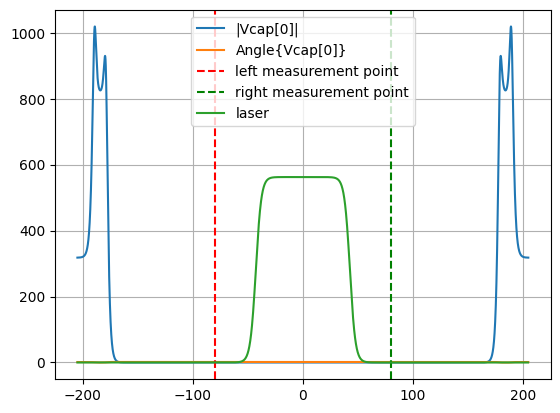

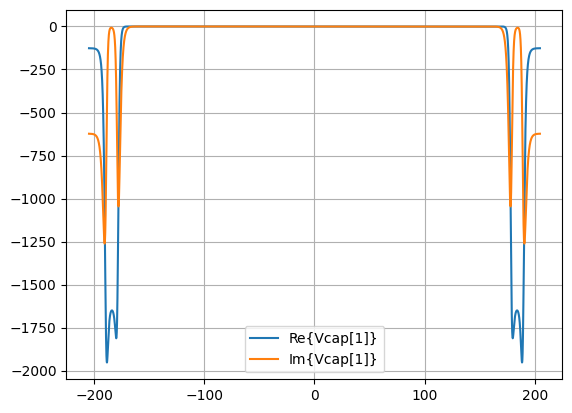

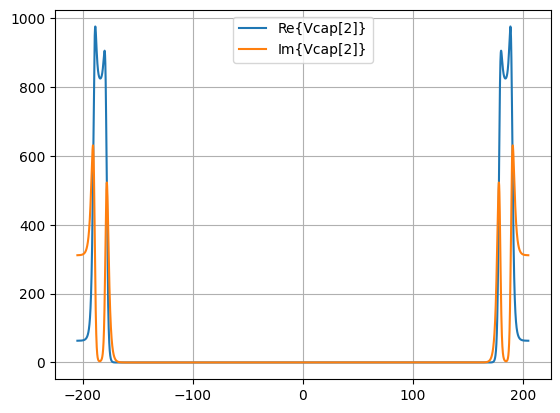

In [26]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.axvline(x=meas_point_left, color='r', linestyle='--', label='left measurement point')
plt.axvline(x=meas_point_right, color='g', linestyle='--', label='right measurement point')
plt.plot(uxgrid[mask_arr],100*laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

In [27]:
# Time evolution with observer approach
# Get sampling ratio from configuration
sampling_ratio = 50

def collect_time_evolution1(psi0_grid, psi1_grid, psi_grid, uxgrid, t, i, utgrid, psi_arr, psi1_arr, ratio=10):
    # Only save every ratio-th time step
    if i % ratio == 0:
        time_index = i // ratio  # New indexing
        psi_arr[:, time_index] = psi_grid
        #psi0_arr[:, time_index] = psi0_grid  # psi0 is not used in this case, so we can skip it
        psi1_arr[:, time_index] = psi1_grid

# Pre-allocate arrays
num_x = len(uxgrid)
num_t = len(utgrid) // sampling_ratio  # Reduce storage according to sampling_ratio
psi_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
#psi0_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
#psi0_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)

# Reduced time grid for plotting
utgrid_reduced = utgrid[::sampling_ratio]

print(f"Array allocation:")
print(f"  Original time grid: {len(utgrid)} points")
print(f"  Reduced time grid: {len(utgrid_reduced)} points")
print(f"  Memory reduction factor: {len(utgrid)/len(utgrid_reduced):.1f}x")

Array allocation:
  Original time grid: 25000 points
  Reduced time grid: 500 points
  Memory reduction factor: 50.0x


In [28]:
v_cap = None

In [29]:
# Calculator1 létrehozása és futtatása pozitív k esetében
calculator1_pk = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

# Futtatás observerrel, eredmények gyűjtése a tömbökbe
calculator1_pk.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr1, psi1_pk_te_arr1, sampling_ratio
))

# Calculator1 létrehozása és futtatása negatív k esetében
calculator1_mk = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

# Futtatás observerrel, eredmények gyűjtése a tömbökbe
calculator1_mk.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr1, psi1_mk_te_arr1, sampling_ratio
))

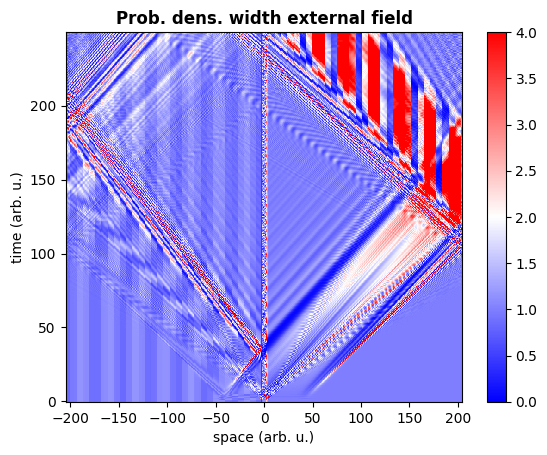

In [30]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,1.2*laserpot.temporal_max])
#plt.xlim([-1.2*laserpot.spatial_max, 1.2*laserpot.spatial_max])
plt.clim([0, 4])
plt.show()

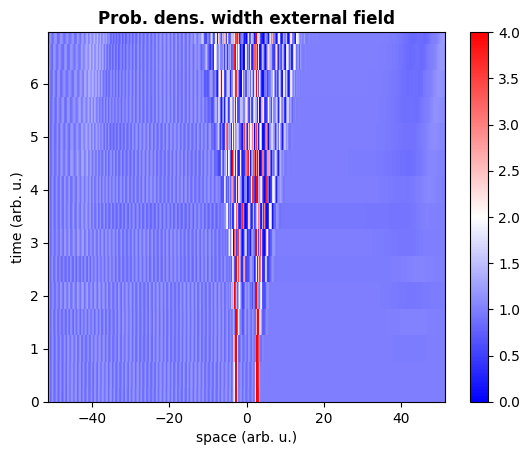

In [31]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,1.2*laserpot.temporal_max])
plt.xlim([-1.2*laserpot.spatial_max, 1.2*laserpot.spatial_max])
plt.clim([0, 4])
plt.show()

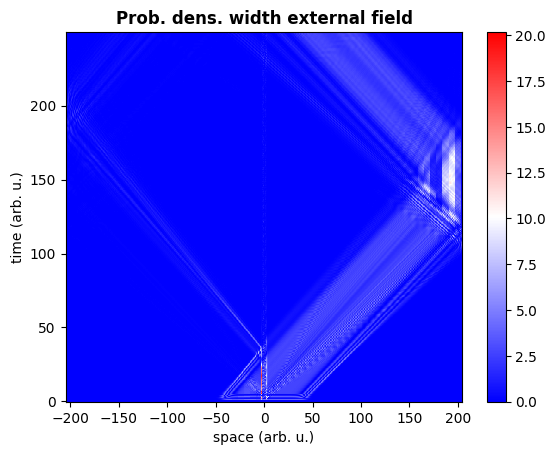

In [32]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(uxgrid[mask_arr], utgrid_reduced)
Z = np.abs(psi1_pk_te_arr1[mask_arr, :])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,25])
plt.show()

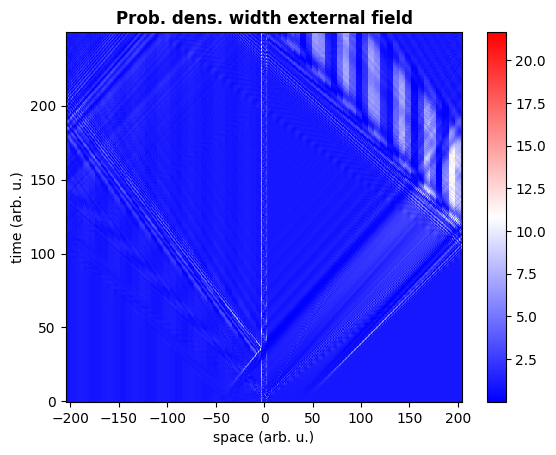

In [33]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(uxgrid[mask_arr], utgrid_reduced)
Z = np.abs(psi_pk_te_arr1[mask_arr, :])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,25])
plt.show()

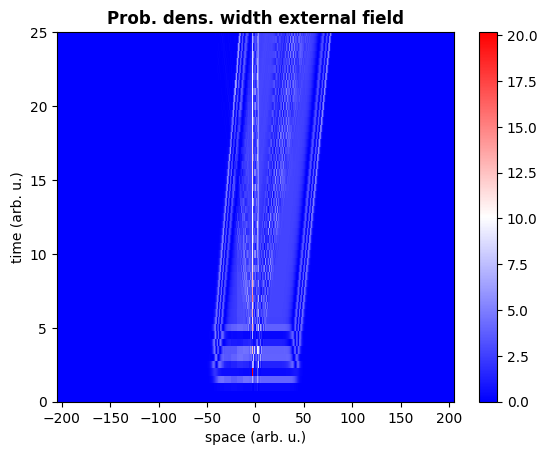

In [34]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi1_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,25])
plt.show()

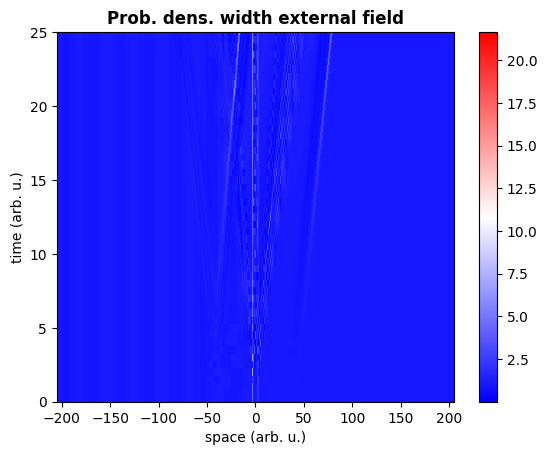

In [35]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,25])
plt.show()

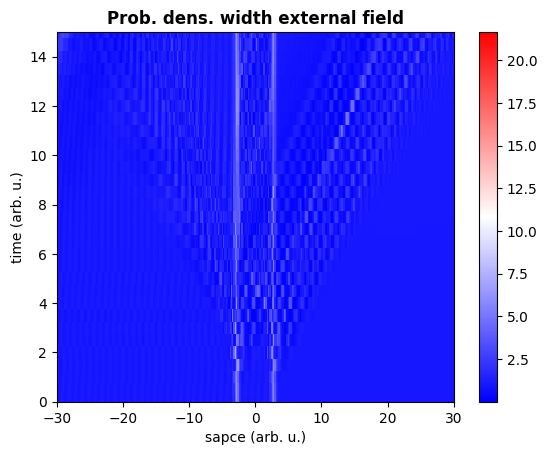

In [36]:
X,Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"),utgrid_reduced)

psi_pk_te_wf = quat.Wavefunction(grid=sim_grid.spatial("uniform_subsampling"), value=psi_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])

Z=np.transpose(quat.probability_density(psi_pk_te_wf))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-30, 30])
plt.ylim([0,15])
plt.show()

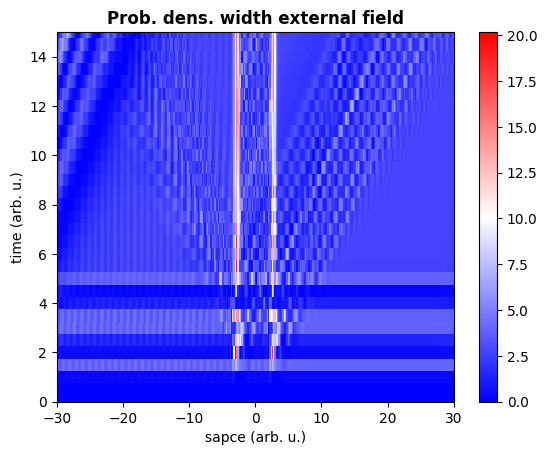

In [37]:
X,Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"),utgrid_reduced)

psi1_pk_te_wf = quat.Wavefunction(grid=sim_grid.spatial("uniform_subsampling"), value=psi1_pk_te_arr1[sim_grid.get_mask('spatial',"uniform_subsampling"),:])

Z=np.transpose(quat.probability_density(psi1_pk_te_wf))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-30, 30])
plt.ylim([0,15])
plt.show()

In [38]:
# Kezdőállapot (t=0) sűrűség
psi_0 = qppk.state.value
density_0 = np.abs(psi_0)**2
norm_0 = np.trapz(density_0, uxgrid)

# Időfejlesztett állapot utolsó időpontban
psi_final = psi_pk_te_arr1[:,-1]
density_final = np.abs(psi_final)**2
norm_final = np.trapz(density_final, uxgrid)

# Különbség és relatív eltérés
abs_diff = np.abs(norm_final - norm_0)
rel_diff = abs_diff / norm_0 if norm_0 != 0 else np.nan

print(f"Norm (t=0): {norm_0:.6g}, Norm (final): {norm_final:.6g}")
print(f"Abs diff: {abs_diff:.3e}, Rel diff: {rel_diff:.3e}")

Norm (t=0): 415.463, Norm (final): 672.35
Abs diff: 2.569e+02, Rel diff: 6.183e-01


# Compute probability current

In [39]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

4992 11392
-80.0 80.0


In [40]:
pc_pk_left=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr1),left_index)
pc_mk_left=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr1),left_index)
pc_pk_right=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr1),right_index)
pc_mk_right=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr1),right_index)


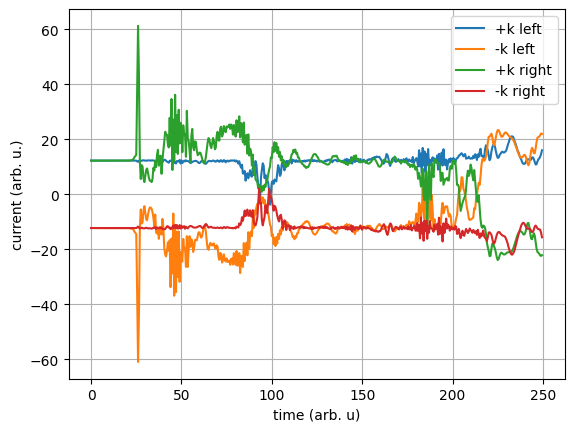

In [41]:
plt.plot(utgrid_reduced, pc_pk_left,label="+k left")
plt.plot(utgrid_reduced, pc_mk_left,label="-k left")
plt.plot(utgrid_reduced, pc_pk_right,label="+k right")
plt.plot(utgrid_reduced, pc_mk_right,label="-k right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

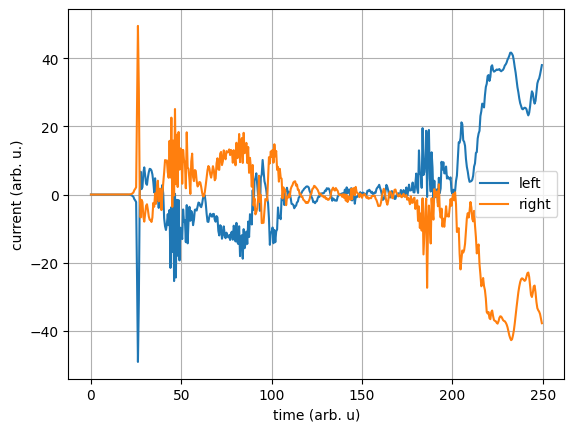

In [42]:
pc_left = pc_pk_left + pc_mk_left
pc_right = pc_pk_right + pc_mk_right
plt.plot(utgrid_reduced, pc_left,label="left")
plt.plot(utgrid_reduced, pc_right,label="right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

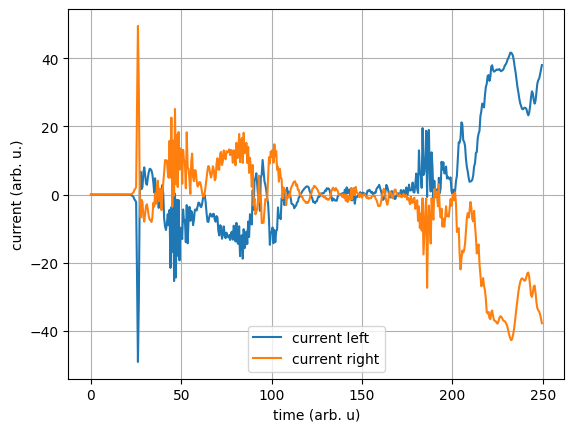

In [43]:
pc_sum_left=pc_left#pc_sum[left_index,:]
pc_sum_right=pc_right#pc_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid_reduced, pc_sum_left,label="current left")
plt.plot(utgrid_reduced, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

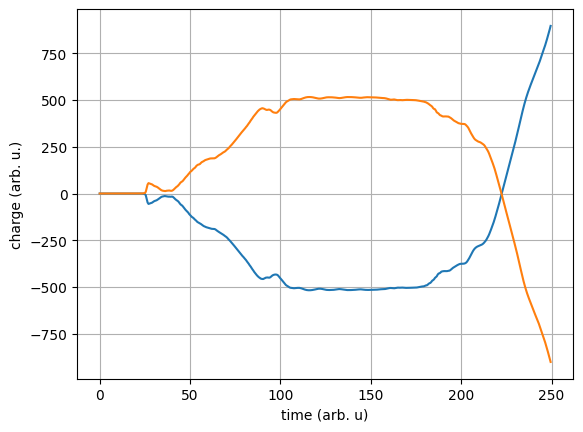

In [44]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid_reduced, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid_reduced, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid_reduced, charge_left,label="charge left")
plt.plot(utgrid_reduced, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

In [45]:
v_cap = quat.vcap_generator(uxgrid, param_x0=160, param_lambda0=0.14, param_theta0=0.25)

psi_pk_te_arr_vcap = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_pk_te_arr_vcap = np.zeros((num_x, num_t), dtype=np.complex128)
psi_mk_te_arr_vcap = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_mk_te_arr_vcap = np.zeros((num_x, num_t), dtype=np.complex128)

# Új időfejlődés futtatása kisebb időlépéssel
calculator_pk_vcap = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_pk_vcap.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr_vcap, psi1_pk_te_arr_vcap, sampling_ratio
))

calculator_mk_vcap = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_mk_vcap.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr_vcap, psi1_mk_te_arr_vcap, sampling_ratio
))

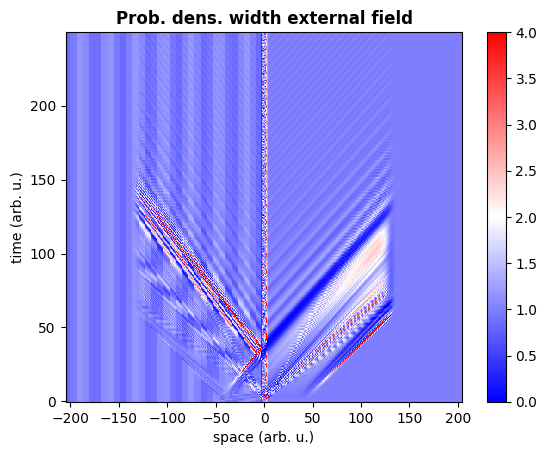

In [46]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi_pk_te_arr_vcap[sim_grid.get_mask('spatial',"uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,1.2*laserpot.temporal_max])
#plt.xlim([-1.2*laserpot.spatial_max, 1.2*laserpot.spatial_max])
plt.clim([0, 4])
plt.show()

In [47]:
pc_pk_left_vcap=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr_vcap),left_index)
pc_mk_left_vcap=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr_vcap),left_index)
pc_pk_right_vcap=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr_vcap),right_index)
pc_mk_right_vcap=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr_vcap),right_index)

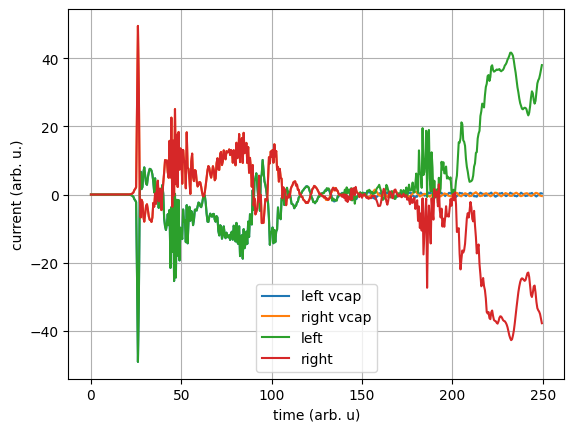

In [48]:
pc_left_vcap = pc_pk_left_vcap + pc_mk_left_vcap
pc_right_vcap = pc_pk_right_vcap + pc_mk_right_vcap
plt.plot(utgrid_reduced, pc_left_vcap,label="left vcap")
plt.plot(utgrid_reduced, pc_right_vcap,label="right vcap")
plt.plot(utgrid_reduced, pc_left,label="left")
plt.plot(utgrid_reduced, pc_right,label="right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

In [49]:
charge_left_vcap = integrate.cumtrapz(pc_left_vcap, utgrid_reduced, initial=0)
charge_right_vcap = integrate.cumtrapz(pc_right_vcap, utgrid_reduced, initial=0)

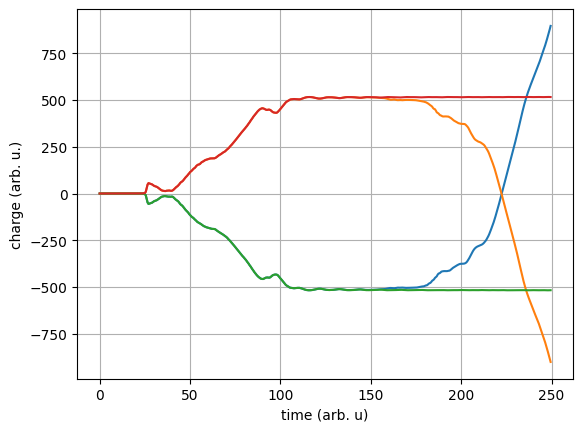

In [50]:
plt.plot(utgrid_reduced, charge_left,label="charge left")
plt.plot(utgrid_reduced, charge_right,label="charge right")
plt.plot(utgrid_reduced, charge_left_vcap,label="charge left")
plt.plot(utgrid_reduced, charge_right_vcap,label="charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
plt.grid()
plt.show()

In [ ]:
# Új időlépés beállítása ( 0.1x kisebb mint az eredeti)
smaller_dt = 0.1 * utgrid_dt
smaller_sampling_ratio = int( utgrid_dt / smaller_dt * sampling_ratio)
utgrid_smaller = np.arange(t_start, t_stop, smaller_dt)
utgrid_smaller_reduced = utgrid_smaller[::smaller_sampling_ratio]

# Új tömbök allokálása
num_x = len(uxgrid)
num_t_smaller = 1 + len(utgrid_smaller) // smaller_sampling_ratio
psi_pk_te_arr_smaller = np.zeros((num_x, num_t_smaller), dtype=np.complex128)
psi1_pk_te_arr_smaller = np.zeros((num_x, num_t_smaller), dtype=np.complex128)

# Új időfejlődés futtatása kisebb időlépéssel
calculator_pk_smaller = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=smaller_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_pk_smaller.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr_smaller, psi1_pk_te_arr_smaller, smaller_sampling_ratio
))

psi_mk_te_arr_smaller = np.zeros((num_x, num_t_smaller), dtype=np.complex128)
psi1_mk_te_arr_smaller = np.zeros((num_x, num_t_smaller), dtype=np.complex128)

calculator_mk_smaller = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=smaller_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_mk_smaller.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr_smaller, psi1_mk_te_arr_smaller, smaller_sampling_ratio
))

In [ ]:
print(num_t_smaller)
print(smaller_sampling_ratio)


25001
10


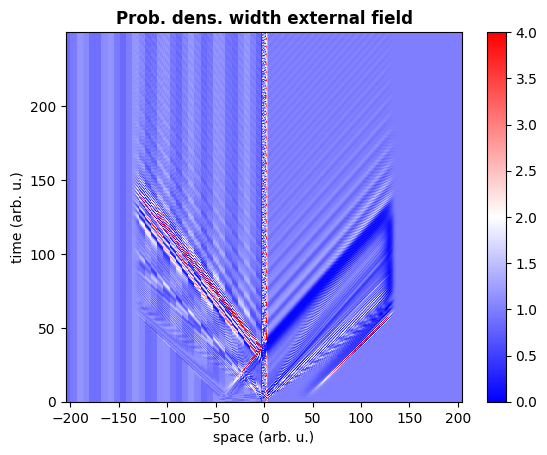

In [ ]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_smaller_reduced)
Z = np.abs(psi_pk_te_arr_smaller[sim_grid.get_mask('spatial',"uniform_subsampling"),:-1])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,1.2*laserpot.temporal_max])
#plt.xlim([-1.2*laserpot.spatial_max, 1.2*laserpot.spatial_max])
plt.clim([0, 4])
plt.show()

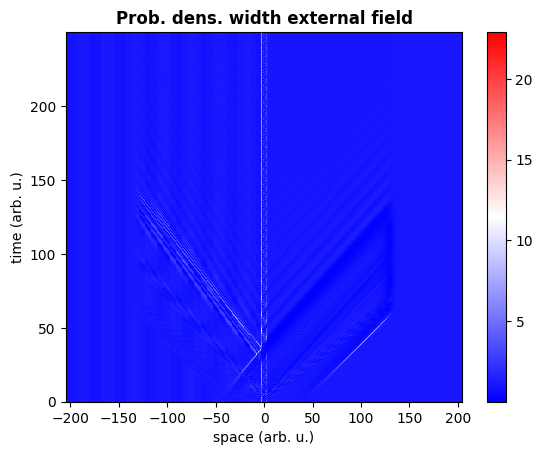

In [ ]:
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_smaller_reduced)
Z = np.abs(psi_pk_te_arr_smaller[sim_grid.get_mask('spatial',"uniform_subsampling"),:-1])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,25])
plt.show()

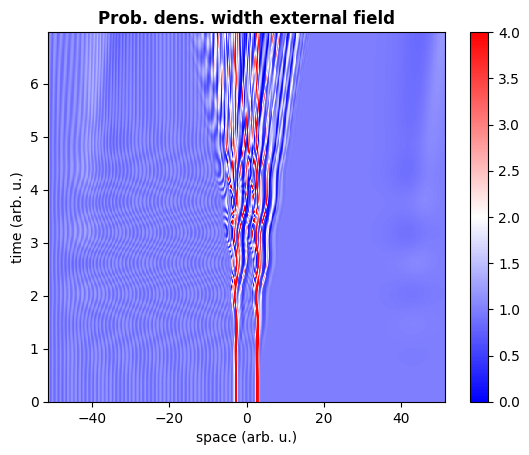

In [ ]:
X, Y = np.meshgrid(sim_grid.spatial("uniform_subsampling"), utgrid_smaller_reduced)
Z = np.abs(psi_pk_te_arr_smaller[sim_grid.get_mask('spatial',"uniform_subsampling"),:-1])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,1.2*laserpot.temporal_max])
plt.xlim([-1.2*laserpot.spatial_max, 1.2*laserpot.spatial_max])
plt.clim([0, 4])
plt.show()

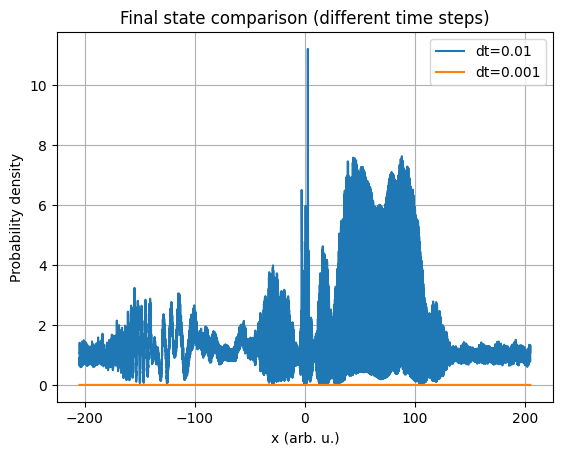

In [ ]:
# Összehasonlítás: például végállapot sűrűség kirajzolása
plt.plot(uxgrid, np.abs(psi_pk_te_arr1[:,-1])**2, label=f'dt={utgrid_dt}')
plt.plot(uxgrid, np.abs(psi_pk_te_arr_smaller[:,-1])**2, label=f'dt={smaller_dt}')
plt.xlabel("x (arb. u.)")
plt.ylabel("Probability density")
plt.legend()
plt.title("Final state comparison (different time steps)")
plt.grid()
plt.show()

In [ ]:
# Áram és töltés összehasonlítása különböző időlépéseknél

# Áram számítása kisebb időlépésnél
pc_pk_left_smaller = quat.probability_current_at(quat.Wavefunction(grid=uxgrid, value=psi_pk_te_arr_smaller), left_index)
pc_pk_right_smaller = quat.probability_current_at(quat.Wavefunction(grid=uxgrid, value=psi_pk_te_arr_smaller), right_index)
pc_mk_left_smaller = quat.probability_current_at(quat.Wavefunction(grid=uxgrid, value=psi_mk_te_arr_smaller), left_index)
pc_mk_right_smaller = quat.probability_current_at(quat.Wavefunction(grid=uxgrid, value=psi_mk_te_arr_smaller), right_index)
pc_left_smaller = pc_pk_left_smaller + pc_mk_left_smaller
pc_right_smaller = pc_pk_right_smaller + pc_mk_right_smaller

# Töltés számítása kisebb időlépésnél
charge_left_smaller = integrate.cumtrapz(pc_left_smaller[:-1], utgrid_smaller_reduced, initial=0)
charge_right_smaller = integrate.cumtrapz(pc_right_smaller[:-1], utgrid_smaller_reduced, initial=0)

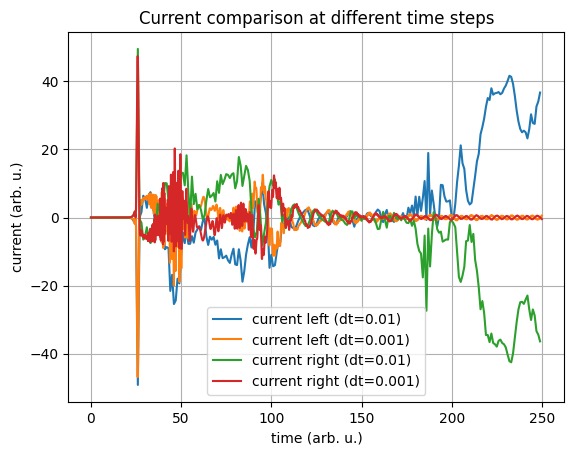

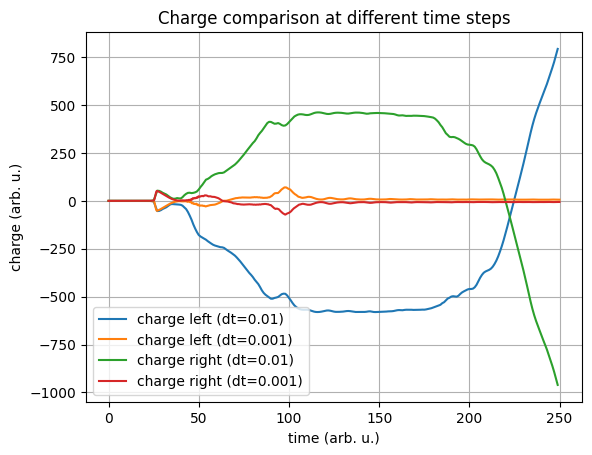

In [ ]:
# Áram összehasonlítása
plt.plot(utgrid_reduced, pc_left, label=f"current left (dt={utgrid_dt})")
plt.plot(utgrid_smaller_reduced, pc_left_smaller[:-1], label=f"current left (dt={smaller_dt})")
plt.plot(utgrid_reduced, pc_right, label=f"current right (dt={utgrid_dt})")
plt.plot(utgrid_smaller_reduced, pc_right_smaller[:-1], label=f"current right (dt={smaller_dt})")
plt.xlabel("time (arb. u.)")
plt.ylabel("current (arb. u.)")
plt.legend()
plt.title("Current comparison at different time steps")
plt.grid()
plt.show()

# Töltés összehasonlítása
plt.plot(utgrid_reduced, charge_left, label=f"charge left (dt={utgrid_dt})")
plt.plot(utgrid_smaller_reduced, charge_left_smaller, label=f"charge left (dt={smaller_dt})")
plt.plot(utgrid_reduced, charge_right, label=f"charge right (dt={utgrid_dt})")
plt.plot(utgrid_smaller_reduced, charge_right_smaller, label=f"charge right (dt={smaller_dt})")
plt.xlabel("time (arb. u.)")
plt.ylabel("charge (arb. u.)")
plt.legend()
plt.title("Charge comparison at different time steps")
plt.grid()
plt.show()

In [ ]:
# Új időlépés beállítása (0.01x kisebb mint az eredeti)
fine_dt = 0.01 * utgrid_dt
fine_sampling_ratio = int(utgrid_dt / fine_dt * sampling_ratio)
print(f"Fine sampling ratio: {fine_sampling_ratio}")
utgrid_fine = np.arange(t_start, t_stop, fine_dt)
utgrid_fine_reduced = utgrid_fine[::fine_sampling_ratio]

# Új tömbök allokálása
num_x = len(uxgrid)
num_t_fine = 1 + len(utgrid_fine) // fine_sampling_ratio
psi_pk_te_arr_fine = np.zeros((num_x, num_t_fine), dtype=np.complex128)
psi1_pk_te_arr_fine = np.zeros((num_x, num_t_fine), dtype=np.complex128)

# Új időfejlődés futtatása kisebb időlépéssel
calculator_pk_fine = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=fine_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_pk_fine.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr_fine, psi1_pk_te_arr_fine, fine_sampling_ratio
))

psi_mk_te_arr_fine = np.zeros((num_x, num_t_fine), dtype=np.complex128)
psi1_mk_te_arr_fine = np.zeros((num_x, num_t_fine), dtype=np.complex128)

calculator_mk_fine = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=fine_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

calculator_mk_fine.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr_fine, psi1_mk_te_arr_fine, fine_sampling_ratio
))

Fine sampling ratio: 10000


MemoryError: Unable to allocate 610. GiB for an array with shape (16384, 2500000) and data type complex128

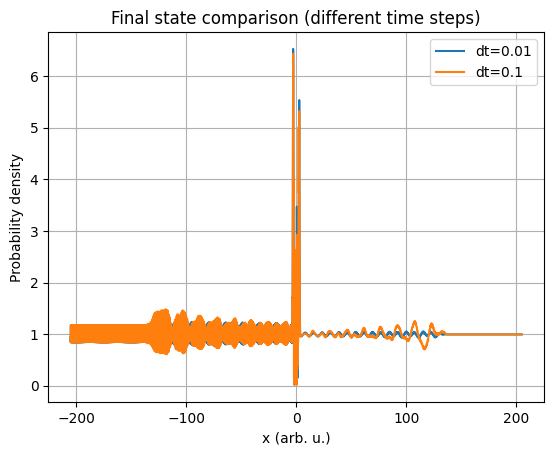

In [ ]:
# Összehasonlítás: például végállapot sűrűség kirajzolása
plt.plot(uxgrid, np.abs(psi_pk_te_arr1[:,-1])**2, label=f'dt={utgrid_dt}')
plt.plot(uxgrid, np.abs(psi_pk_te_arr_fine[:,-1])**2, label=f'dt={fine_dt}')
plt.xlabel("x (arb. u.)")
plt.ylabel("Probability density")
plt.legend()
plt.title("Final state comparison (different time steps)")
plt.grid()
plt.show()